Title:Flood Risk Prediction Using Machine    Learning

Problem Statement:Floods cause heavy losses to life and property. Accurate prediction is essential for early warnings and disaster management.

Description:This project uses historical weather and flood data to train a machine learning model for predicting flood risk levels (Low, Medium, High). It involves data preprocessing, model training, and evaluation to help authorities take preventive measures effectively.

In [ ]:
!pip install kaggle -q


In [ ]:
# Upload your Kaggle API key (kaggle.json)
from google.colab import files
files.upload()   # Choose kaggle.json from your computer (get from Kaggle -> Account -> API -> Create New Token)



Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"sruthikaramagoni","key":"b13940f55c96bbdb45879748ac9b61c8"}'}

In [ ]:
# Move kaggle.json to correct path
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets list -s flood

ref                                                  title                                                size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------  --------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
faizalkarim/flood-area-segmentation                  Flood Area Segmentation                         112072442  2022-12-16 18:29:49.110000           9549        107  1.0              
naiyakhalid/flood-prediction-dataset                 Flood Prediction Dataset                           696132  2024-06-26 14:28:37.673000           6851         62  0.9411765        
rahultp97/louisiana-flood-2016                       Louisiana flood 2016                             96057695  2020-09-01 08:08:00.587000            791         14  0.9411765        
kmader/floodlight-ms-dataset                         Floodlight Open Dataset    

In [ ]:
!kaggle datasets download -d naiyakhalid/flood-prediction-dataset
!unzip flood-prediction-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/naiyakhalid/flood-prediction-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
  0% 0.00/680k [00:00<?, ?B/s]
100% 680k/680k [00:00<00:00, 712MB/s]
Archive:  flood-prediction-dataset.zip
  inflating: flood.csv               


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from imblearn.over_sampling import SMOTE  # pip install imbalanced-learn



In [ ]:
data = pd.read_csv("flood.csv")
print("Dataset shape:", data.shape)
print(data.head())


Dataset shape: (50000, 21)
   MonsoonIntensity  TopographyDrainage  RiverManagement  Deforestation  \
0                 3                   8                6              6   
1                 8                   4                5              7   
2                 3                  10                4              1   
3                 4                   4                2              7   
4                 3                   7                5              2   

   Urbanization  ClimateChange  DamsQuality  Siltation  AgriculturalPractices  \
0             4              4            6          2                      3   
1             7              9            1          5                      5   
2             7              5            4          7                      4   
3             3              4            1          4                      6   
4             5              8            5          2                      7   

   Encroachments  ...  DrainageSyst

In [ ]:
data = pd.read_csv("flood.csv")   # use your dataset file
print("Dataset shape:", data.shape)
print(data.head())
print("Columns:", data.columns)



Dataset shape: (50000, 21)
   MonsoonIntensity  TopographyDrainage  RiverManagement  Deforestation  \
0                 3                   8                6              6   
1                 8                   4                5              7   
2                 3                  10                4              1   
3                 4                   4                2              7   
4                 3                   7                5              2   

   Urbanization  ClimateChange  DamsQuality  Siltation  AgriculturalPractices  \
0             4              4            6          2                      3   
1             7              9            1          5                      5   
2             7              5            4          7                      4   
3             3              4            1          4                      6   
4             5              8            5          2                      7   

   Encroachments  ...  DrainageSyst

In [ ]:
# Target = Floodprobability
X = data.drop("FloodProbability", axis=1)
y = data["FloodProbability"]

# Convert probability into binary classification (Flood=1 if >0.5 else 0)
y_class = (y > 0.5).astype(int)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Handle imbalance using SMOTE
sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_scaled, y_class)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
model = RandomForestClassifier(
    n_estimators=300, max_depth=10, class_weight="balanced", random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.90      0.89      5258
           1       0.90      0.88      0.89      5344

    accuracy                           0.89     10602
   macro avg       0.89      0.89      0.89     10602
weighted avg       0.89      0.89      0.89     10602

ROC-AUC Score: 0.9639523847891893


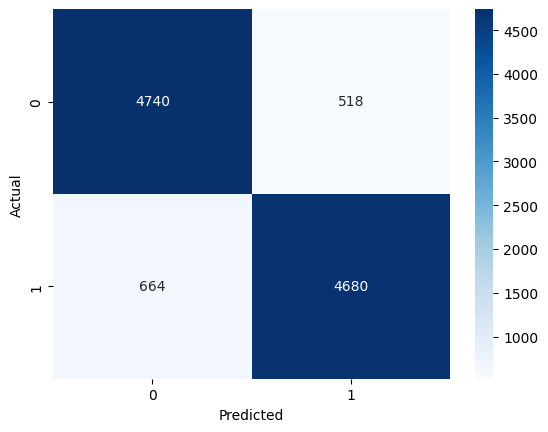

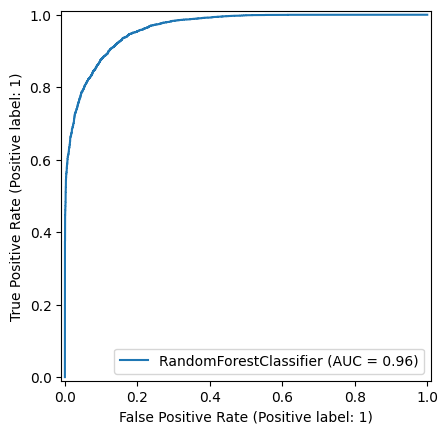

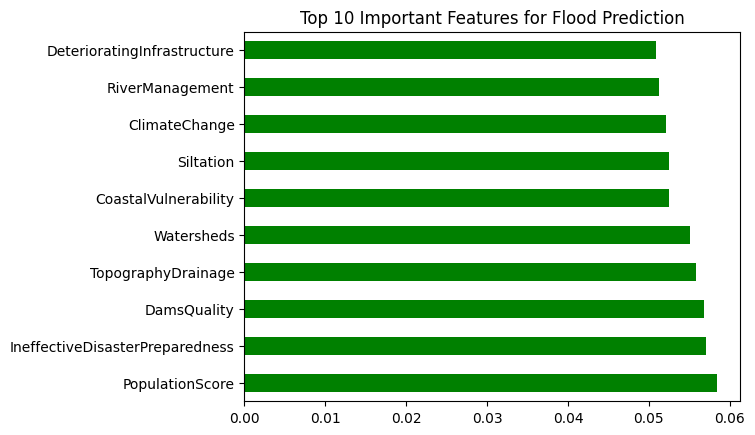

In [ ]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.show()

# Feature Importance
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', color="green")
plt.title("Top 10 Important Features for Flood Prediction")
plt.show()


In [ ]:
print(data.columns.tolist())

['MonsoonIntensity', 'TopographyDrainage', 'RiverManagement', 'Deforestation', 'Urbanization', 'ClimateChange', 'DamsQuality', 'Siltation', 'AgriculturalPractices', 'Encroachments', 'IneffectiveDisasterPreparedness', 'DrainageSystems', 'CoastalVulnerability', 'Landslides', 'Watersheds', 'DeterioratingInfrastructure', 'PopulationScore', 'WetlandLoss', 'InadequatePlanning', 'PoliticalFactors', 'FloodProbability']


In [ ]:
features_names=X.columns.tolist()
example_values=[[7,8,7,6,7,5,8,7,9,5,8,7,7,6,9,8,7,8,6,8]]
example=pd.DataFrame(example_values,columns=features_names)

In [ ]:
example_scaled = scaler.transform(example)
prediction = model.predict(example_scaled)
print("Flood Prediction (1=Flood, 0=No Flood):", prediction[0])

# probability score
probability = model.predict_proba(example_scaled)
print("Flood Risk Probability:", probability[0][1])

Flood Prediction (1=Flood, 0=No Flood): 1
Flood Risk Probability: 0.9765007355484733
